# Light Curve Viewer
Reads and plots the merged pipeline output for a given target and observation night.

In [22]:
# ── Parameters ─────────────────────────────────────────────────────────────────
# Edit these two values before running the notebook

TARGET   = "2001_EC"     # Name of the target folder
NIGHT    = "26_02_28"   # Observation night folder (e.g. '2024-07-15')
MAIN_DIR = "data/"            # Path to the main folder containing target subfolders

In [23]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [24]:
# ── Locate the merged data file ────────────────────────────────────────────────

merged_file = "pipelineout_datasubset_all.dat"

if not os.path.isfile(merged_file):
    sys.exit(
        f"Merged file not found:\n  {merged_file}\n"
        "Run merge_pipeline_dat.py first, or check TARGET / NIGHT / MAIN_DIR."
    )

print(f"Reading: {merged_file}")

Reading: pipelineout_datasubset_all.dat


In [25]:
# ── Load data ──────────────────────────────────────────────────────────────────
# The header line starts with '#', so we strip that character for clean column names

df = pd.read_csv(merged_file, sep="\t", comment=None, header=0)

# Strip the leading '#' from the first column name
df.columns = [c.lstrip("#").strip() for c in df.columns]

print(f"Loaded {len(df)} rows.")
print(f"Columns: {list(df.columns)}")
df.head()

Loaded 348 rows.
Columns: ['', 'Label', 'J.D.-2400000', 'rel_flux_T1', 'rel_flux_err_T1']


,,Label,J.D.-2400000,rel_flux_T1,rel_flux_err_T1
0,1,K01E00C-S001-R001-C001-R_out.fits,61100.719802,0.338610,0.009054
1,2,K01E00C-S001-R001-C002-R_out.fits,61100.720313,0.366528,0.009329
2,3,K01E00C-S001-R001-C003-R_out.fits,61100.720812,0.354604,0.009268
3,4,K01E00C-S001-R001-C004-R_out.fits,61100.721314,0.360991,0.009223
4,5,K01E00C-S001-R001-C005-R_out.fits,61100.721822,0.355784,0.009255


In [26]:
from utils.light_curve import sanity_check, plot_light_curve

In [27]:
sanity_check(df)

J.D.-2400000    : 61100.719802  →  61100.899266
rel_flux_T1: 0.324830  →  0.406033
Median flux error: 0.007824


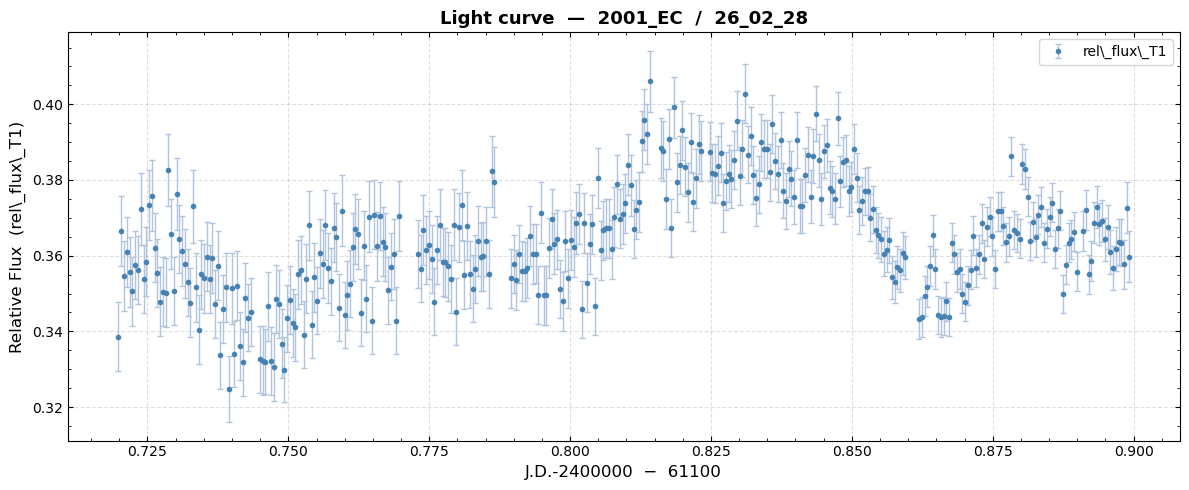

In [28]:
plot_light_curve(TARGET, NIGHT, df["J.D.-2400000"], df["rel_flux_T1"], df["rel_flux_err_T1"])